In [32]:
# ── 1. Import Libraries ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, silhouette_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

import xgboost as xgb

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


## Step 1: Load Dataset

In [33]:
# ── 2. Load Data ─────────────────────────────────────────────────────────────
df = pd.read_csv('Country-data.csv')

print(f" Shape       : {df.shape}")
print(f" Features    : {df.shape[1]-1} (+ 1 country name column)")
print(f" Countries   : {df.shape[0]}")
print()
df.head(10)


 Shape       : (167, 10)
 Features    : 9 (+ 1 country name column)
 Countries   : 167



,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


##  Step 2: Exploratory Data Analysis (EDA)

In [34]:
# ── 3. Basic Info ────────────────────────────────────────────────────────────
print(" Dataset Info:")
df.info()
print()
print(" Statistical Summary:")
df.describe().round(2)


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

 Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [35]:
# ── 4. Missing Values ────────────────────────────────────────────────────────
print(" Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else " No missing values found!")


 Missing Values:
 No missing values found!


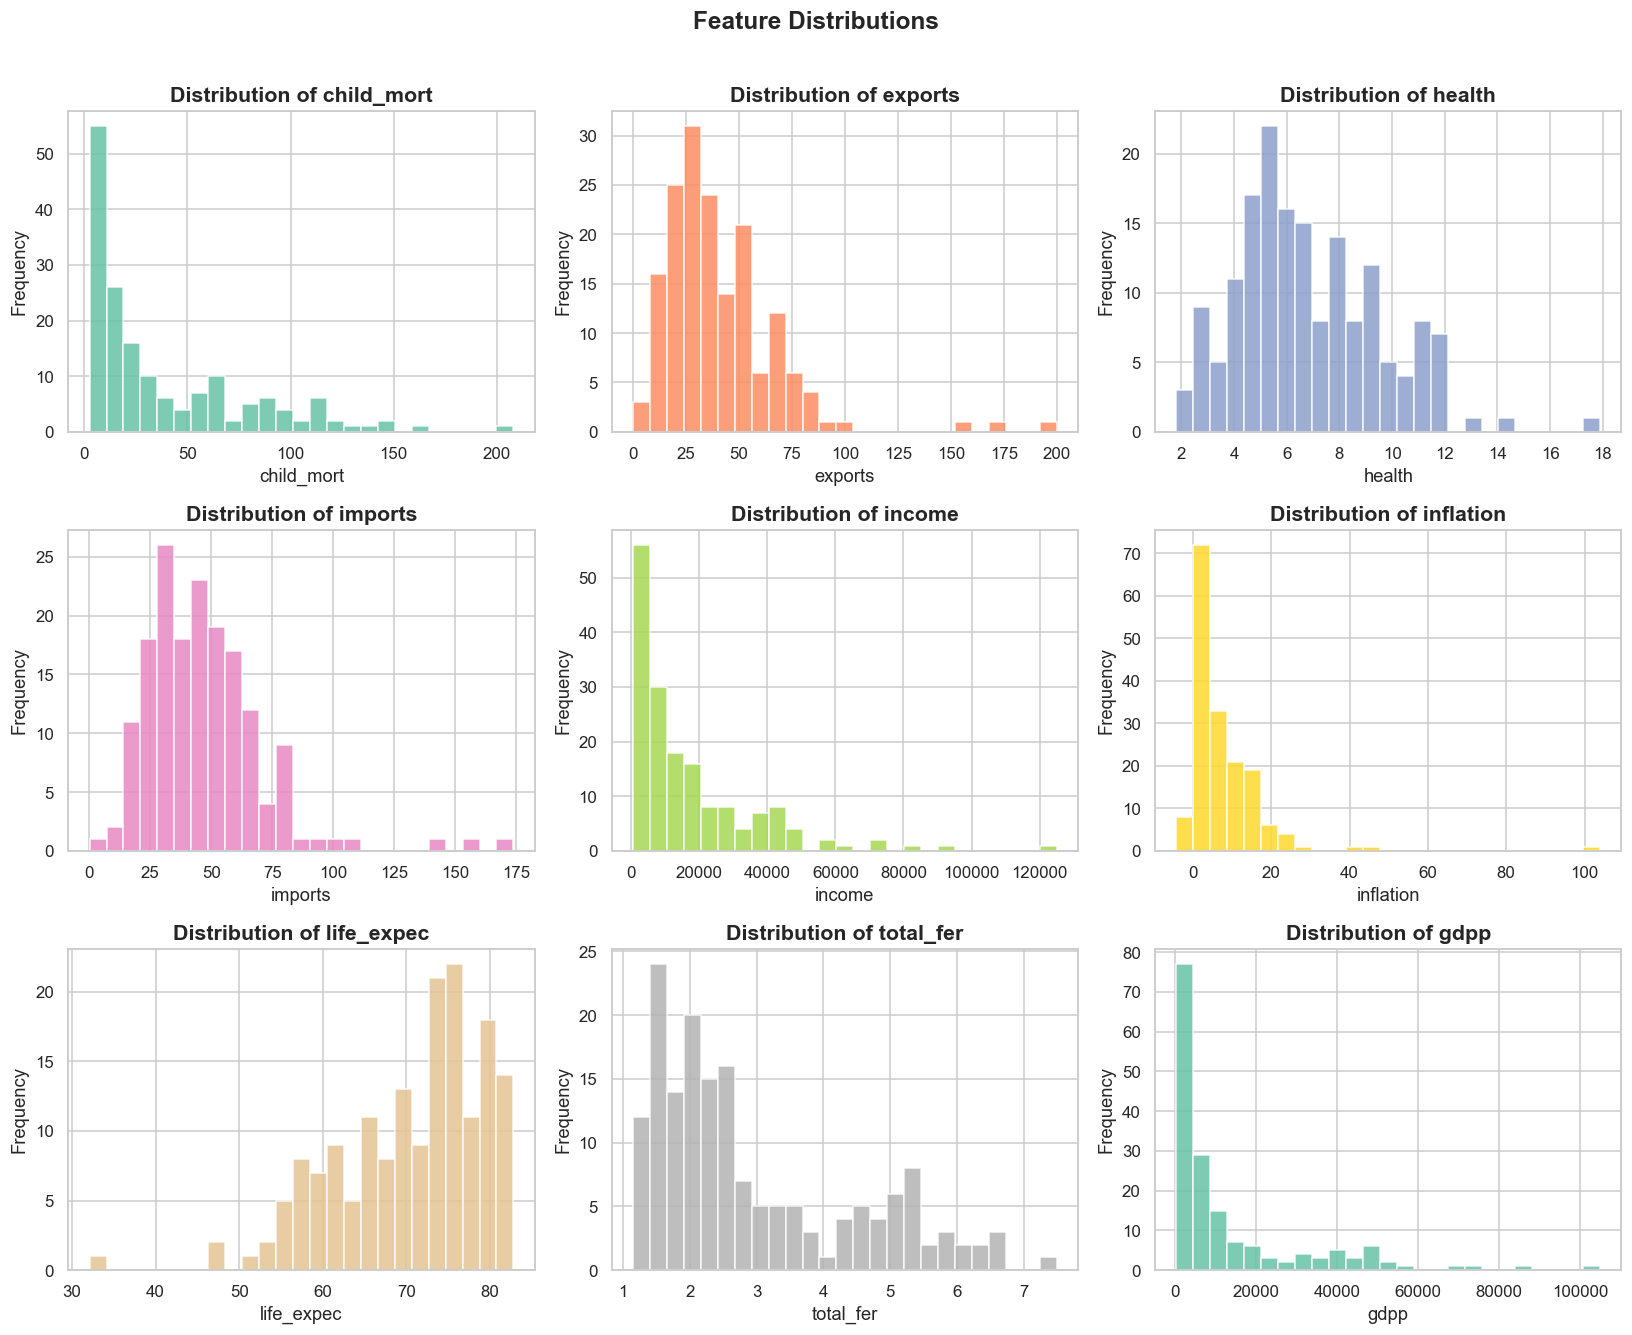

 Distribution plots saved.


In [36]:
# ── 5. Distribution Plots ────────────────────────────────────────────────────
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

colors = sns.color_palette("Set2", 9)
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print(" Distribution plots saved.")


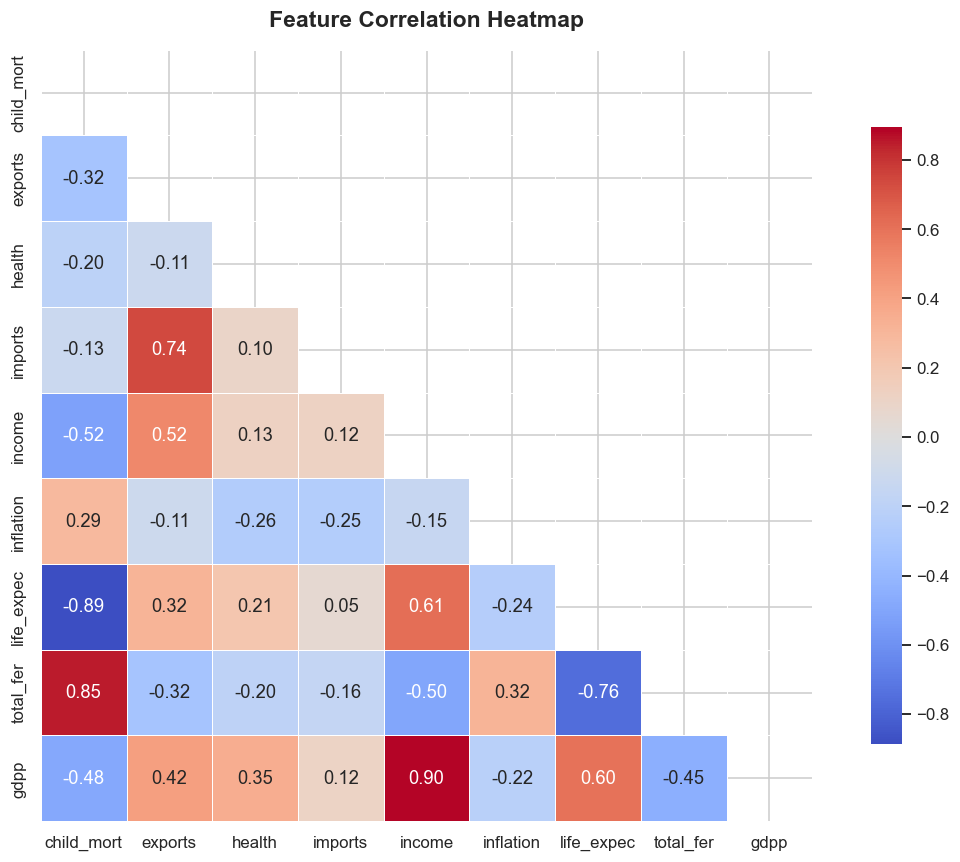

In [37]:
# ── 6. Correlation Heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(11, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()


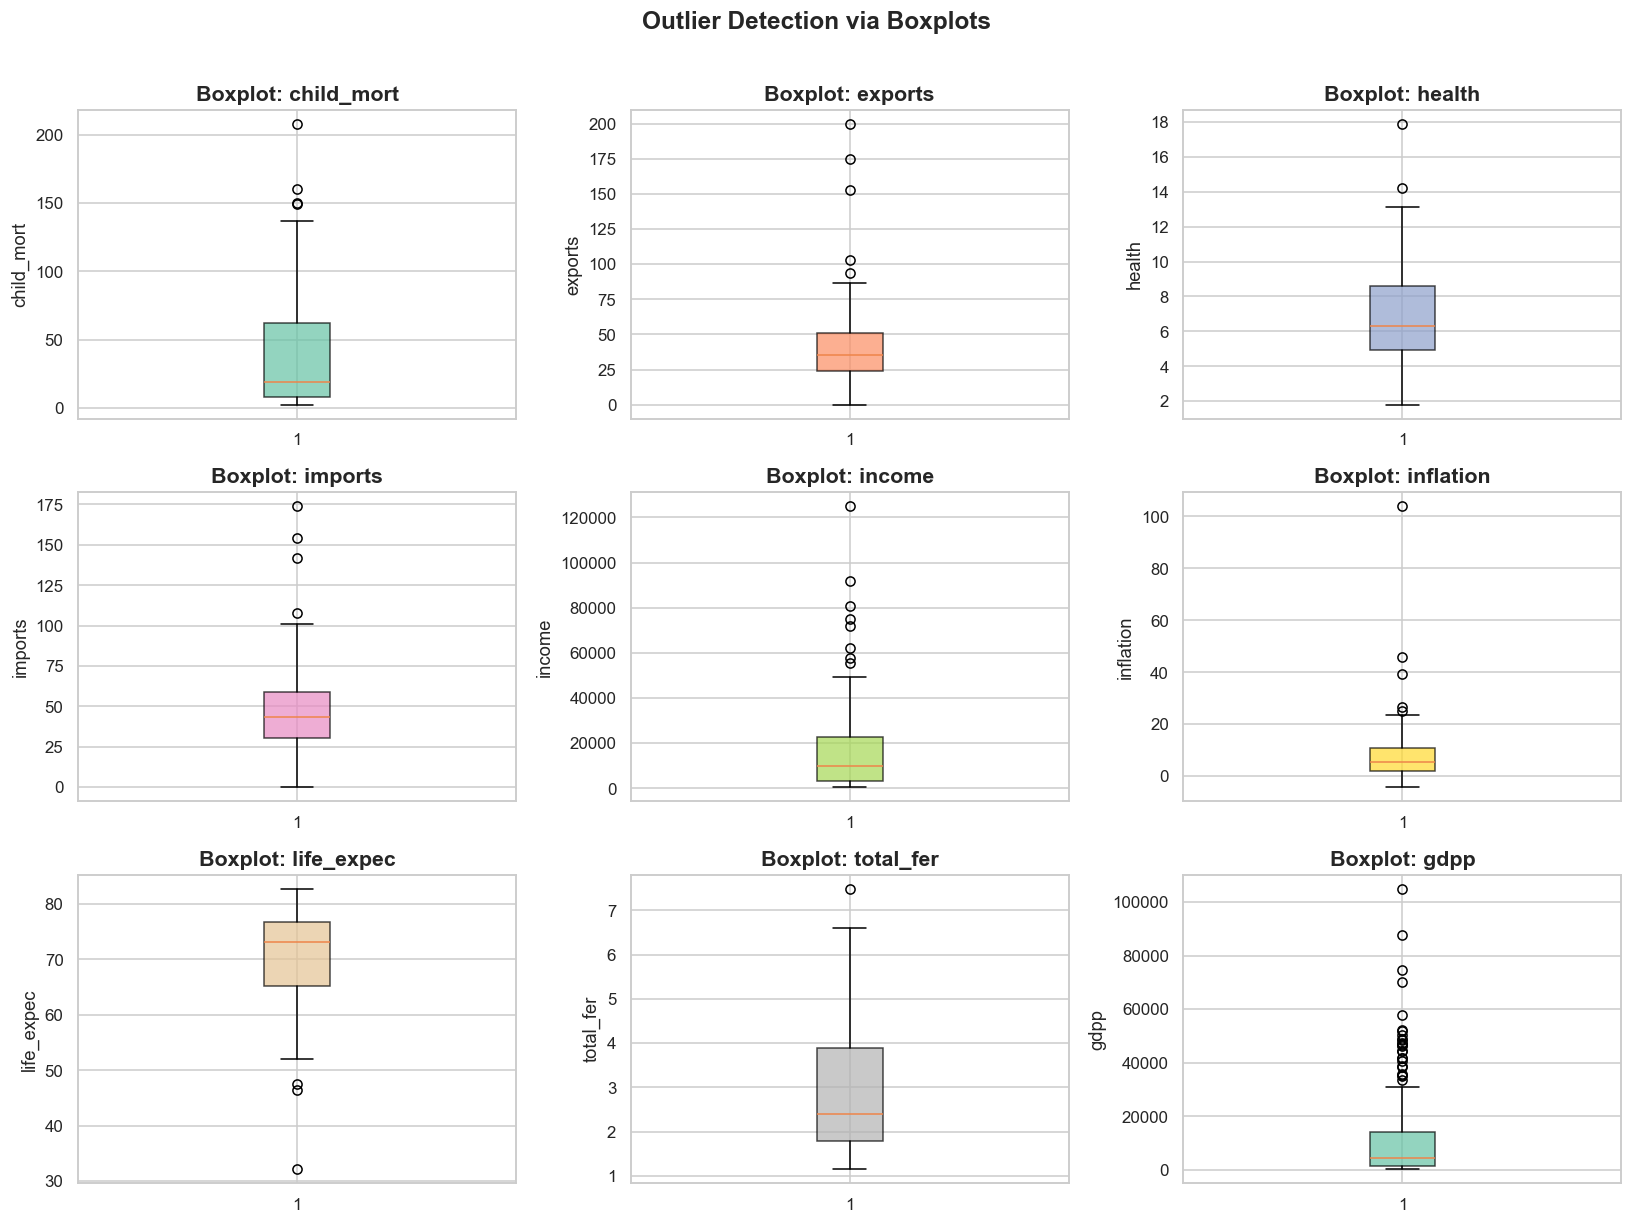

In [38]:
# ── 7. Boxplots for Outlier Detection ────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection via Boxplots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()


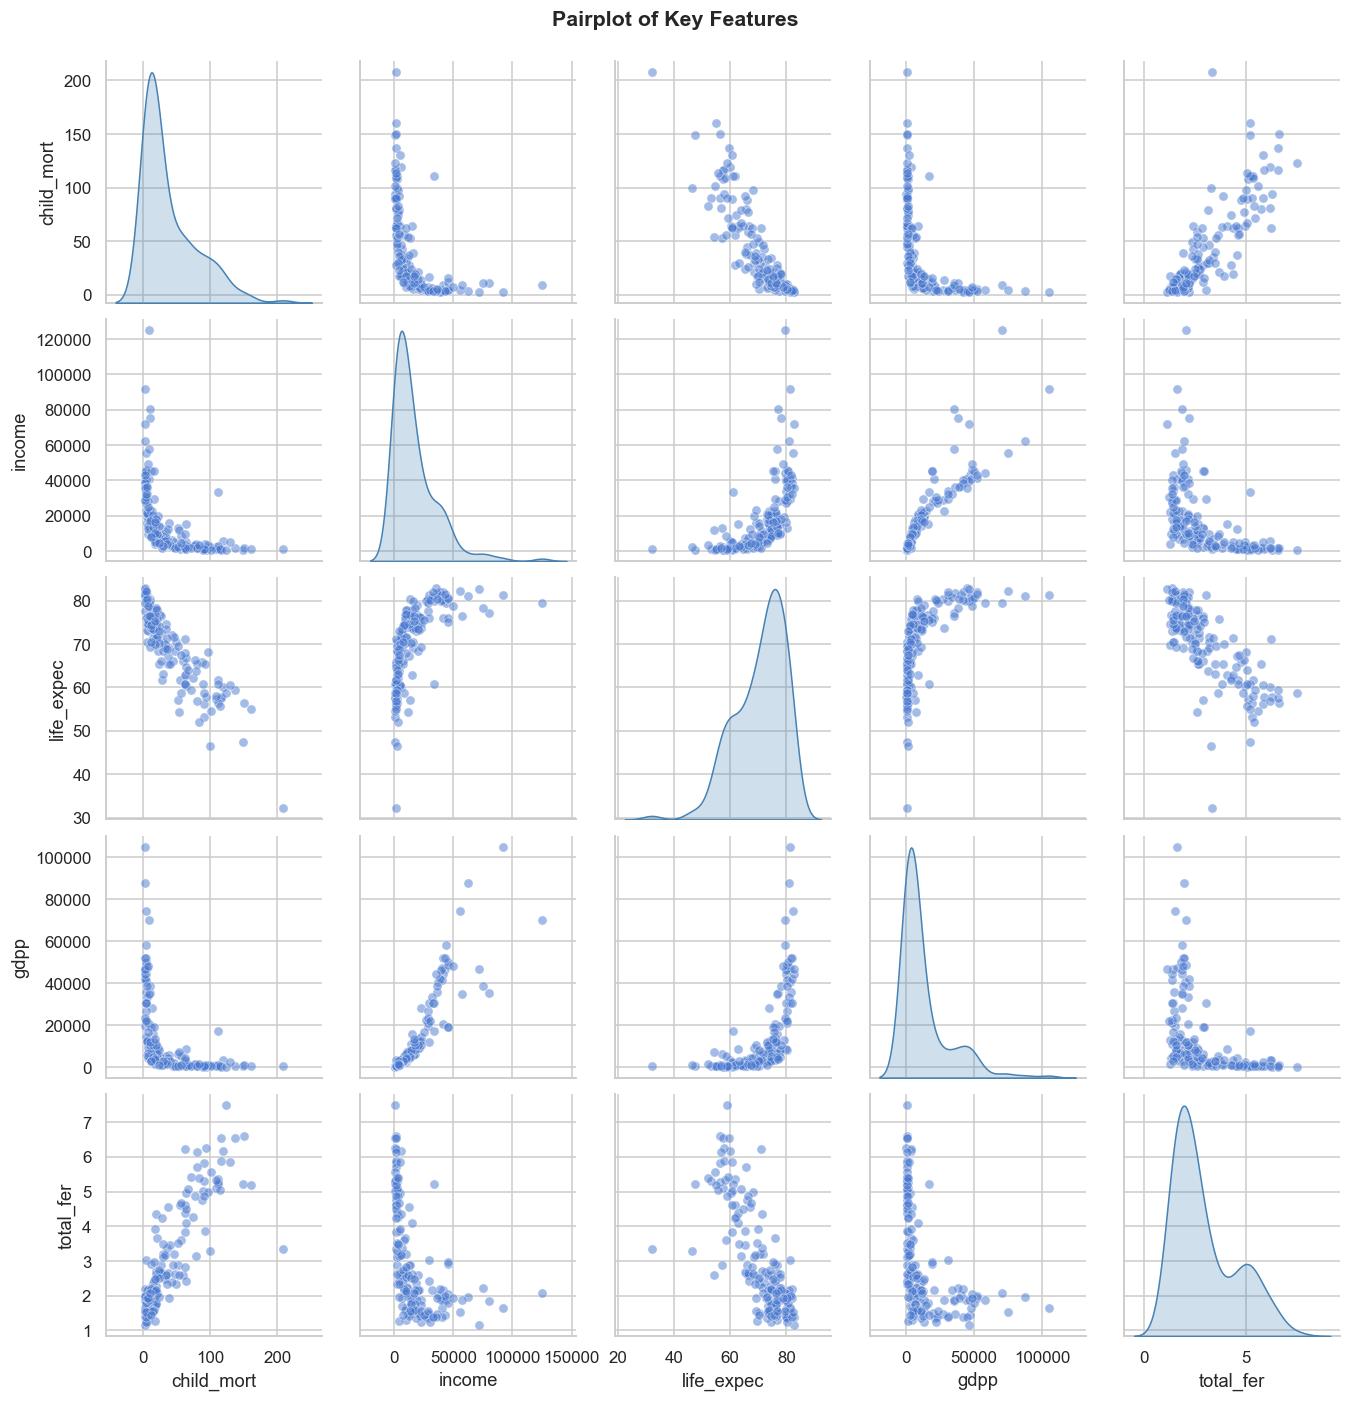

In [39]:
# ── 8. Pairplot (key features) ───────────────────────────────────────────────
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer']
pair_df = df[key_features].copy()
fig = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.5},
                   diag_kws={'color': 'steelblue'})
fig.figure.suptitle('Pairplot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('eda_pairplot.png', bbox_inches='tight')
plt.show()


##  Step 3: Data Preprocessing & Feature Scaling

In [40]:
# ── 9. Feature Scaling ───────────────────────────────────────────────────────
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print(" Data scaled using StandardScaler")
print(f"   Mean (should be ~0): {X_scaled.mean():.4f}")
print(f"   Std  (should be ~1): {X_scaled.std():.4f}")
X_scaled_df.head()


 Data scaled using StandardScaler
   Mean (should be ~0): 0.0000
   Std  (should be ~1): 1.0000


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


##  Step 4: Dimensionality Reduction with PCA

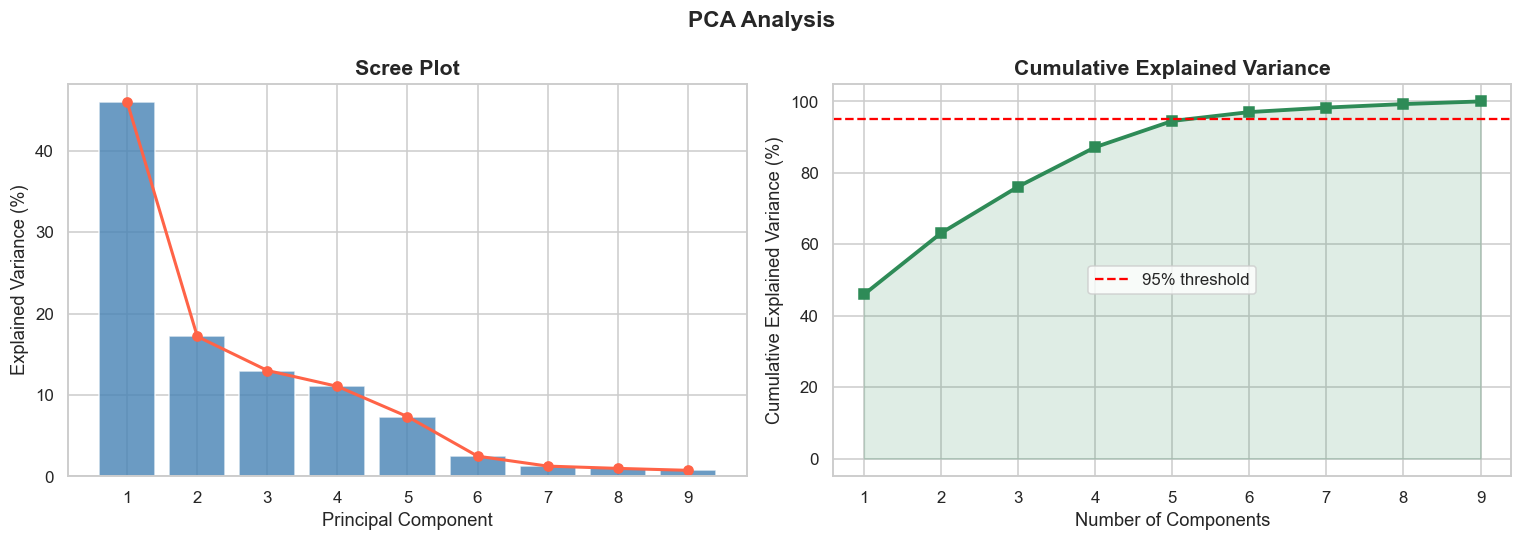


 Components needed to explain 95% variance: 6
 2D PCA variance explained: 63.1%


In [41]:
# ── 10. PCA ──────────────────────────────────────────────────────────────────
pca = PCA(n_components=9)
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
axes[0].bar(range(1, 10), explained * 100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, 10), explained * 100, 'o-', color='tomato', linewidth=2)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xticks(range(1, 10))

# Cumulative Variance
axes[1].plot(range(1, 10), cumulative * 100, 's-', color='seagreen', linewidth=2.5, markersize=7)
axes[1].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[1].fill_between(range(1, 10), cumulative * 100, alpha=0.15, color='seagreen')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(1, 10))

plt.suptitle('PCA Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_analysis.png', bbox_inches='tight')
plt.show()

n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"\n Components needed to explain 95% variance: {n_components_95}")

# Apply PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f" 2D PCA variance explained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")


##  Step 5: K-Means Clustering

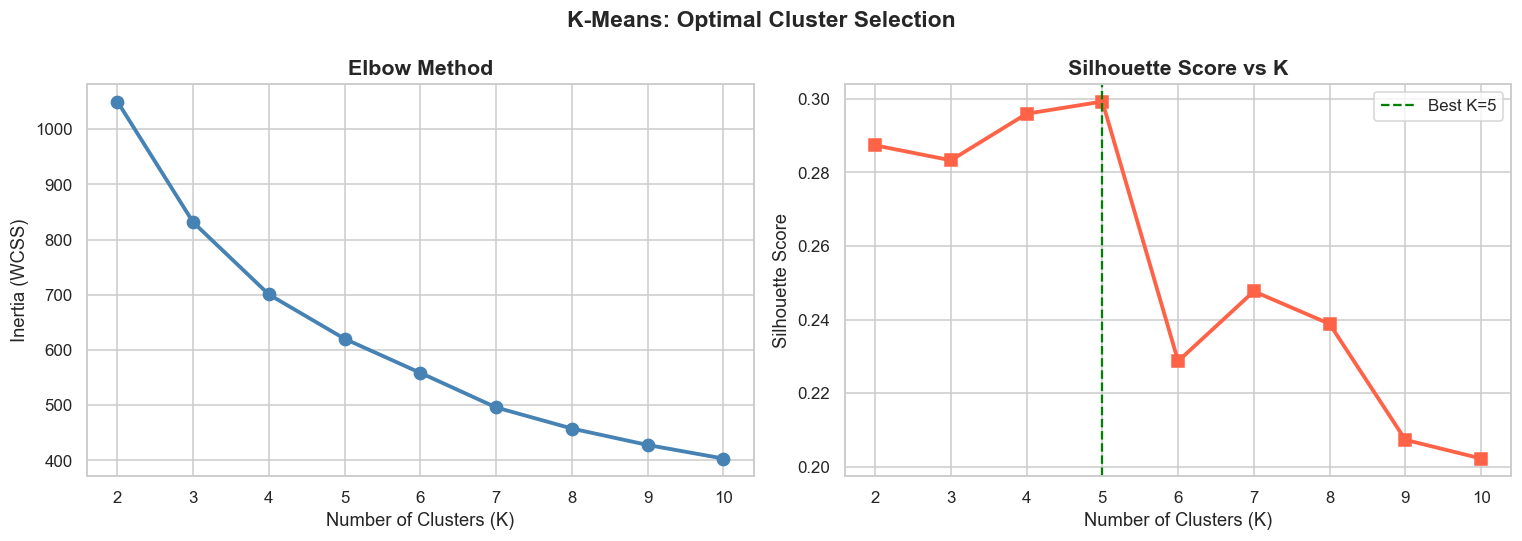

 Best K by Silhouette Score: 5
   Silhouette Score at K=5: 0.2993


In [42]:
# ── 11. Elbow Method + Silhouette ────────────────────────────────────────────
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'o-', color='steelblue', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, silhouette_scores, 's-', color='tomato', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xticks(list(K_range))

best_k = K_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('K-Means: Optimal Cluster Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', bbox_inches='tight')
plt.show()

print(f" Best K by Silhouette Score: {best_k}")
print(f"   Silhouette Score at K={best_k}: {max(silhouette_scores):.4f}")


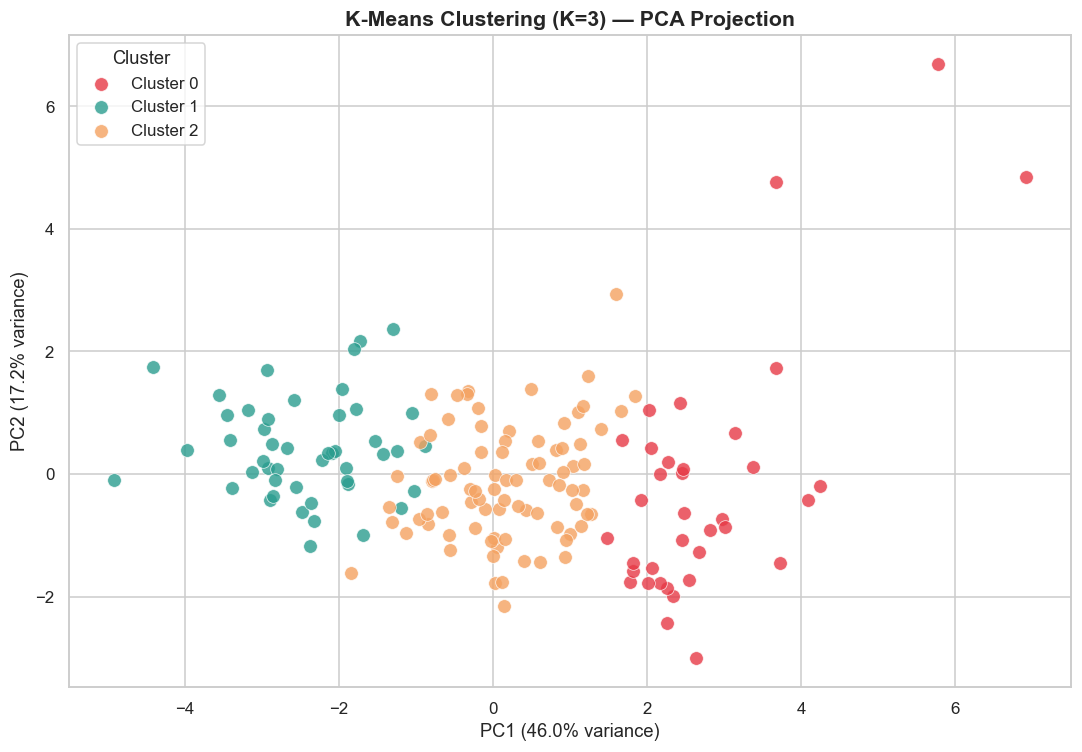

 K-Means applied with K=3
Cluster distribution:
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64


In [43]:
# ── 12. Apply Final K-Means ──────────────────────────────────────────────────
OPTIMAL_K = 3   # Developed / Developing / Underdeveloped

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

# Visualize clusters in 2D PCA space
plt.figure(figsize=(10, 7))
palette = ['#E63946', '#2A9D8F', '#F4A261']
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for cluster in range(OPTIMAL_K):
    mask = kmeans_labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=palette[cluster], label=f'Cluster {cluster}',
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title(f'K-Means Clustering (K={OPTIMAL_K}) — PCA Projection', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=11)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight')
plt.show()

print(f" K-Means applied with K={OPTIMAL_K}")
print("Cluster distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())


 Cluster Profiles (Feature Means):
KMeans_Cluster         0        1         2
child_mort          5.00    92.96     21.93
exports            58.74    29.15     40.24
health              8.81     6.39      6.20
imports            51.49    42.32     47.47
income          45672.22  3942.40  12305.60
inflation           2.67    12.02      7.60
life_expec         80.13    59.19     72.81
total_fer           1.75     5.01      2.31
gdpp            42494.44  1922.38   6486.45


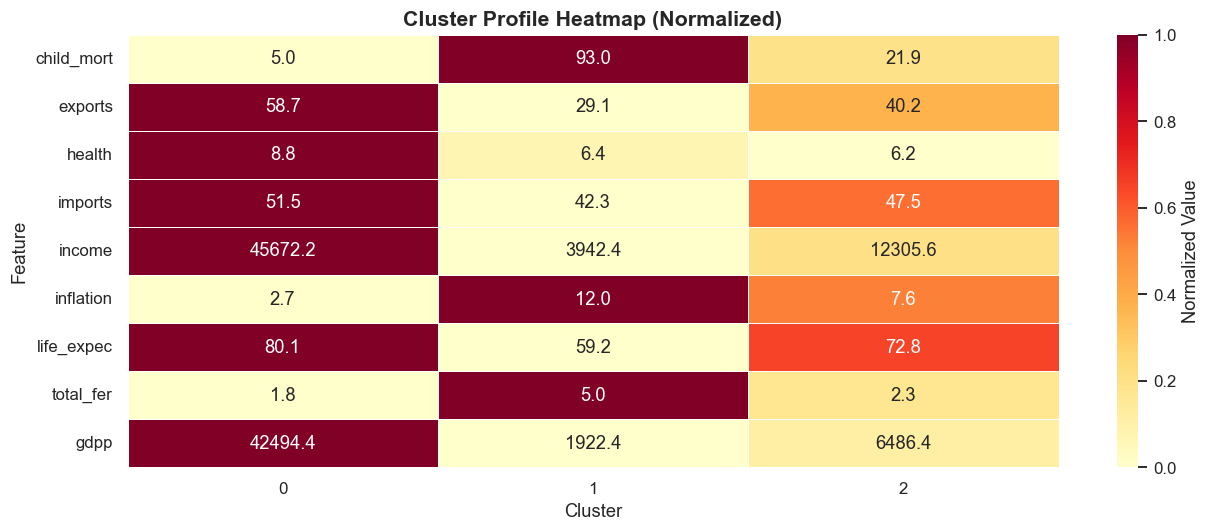


 Cluster Labels Assigned:
Development_Stage
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64


In [44]:
# ── 13. Cluster Profiling ────────────────────────────────────────────────────
cluster_profile = df.groupby('KMeans_Cluster')[features].mean().round(2)
print(" Cluster Profiles (Feature Means):")
print(cluster_profile.T)

# Radar-style heatmap
plt.figure(figsize=(12, 5))
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(profile_norm.T, annot=cluster_profile.T.values, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Normalized Value'})
plt.title('Cluster Profile Heatmap (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('cluster_profiles.png', bbox_inches='tight')
plt.show()

# Name the clusters based on profile
income_by_cluster = cluster_profile['income'].to_dict()
sorted_clusters = sorted(income_by_cluster, key=income_by_cluster.get, reverse=True)
cluster_map = {sorted_clusters[0]: 'Developed', sorted_clusters[1]: 'Developing', sorted_clusters[2]: 'Underdeveloped'}
df['Development_Stage'] = df['KMeans_Cluster'].map(cluster_map)
print("\n Cluster Labels Assigned:")
print(df['Development_Stage'].value_counts())


##  Step 6: DBSCAN Clustering

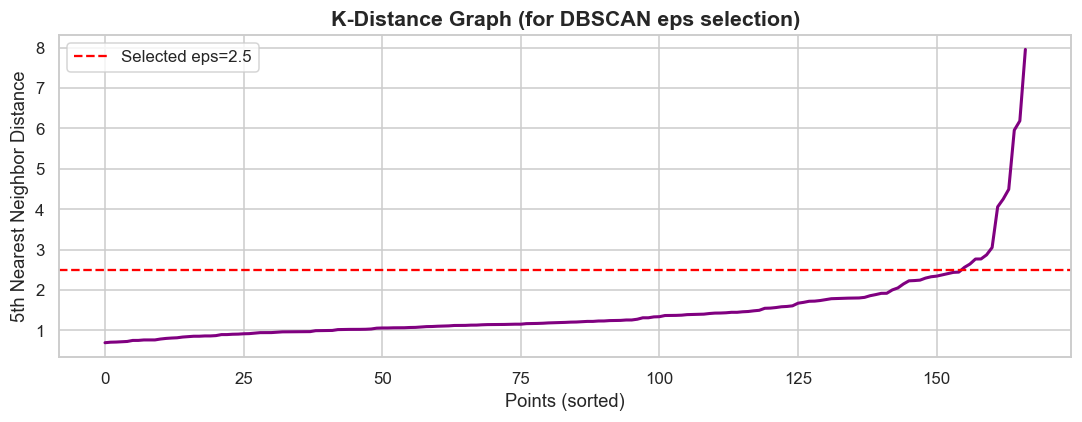

 DBSCAN Results:
   Clusters found   : 1
   Noise points     : 6 (3.6%)
   Cluster distribution: {0: 161, -1: 6}


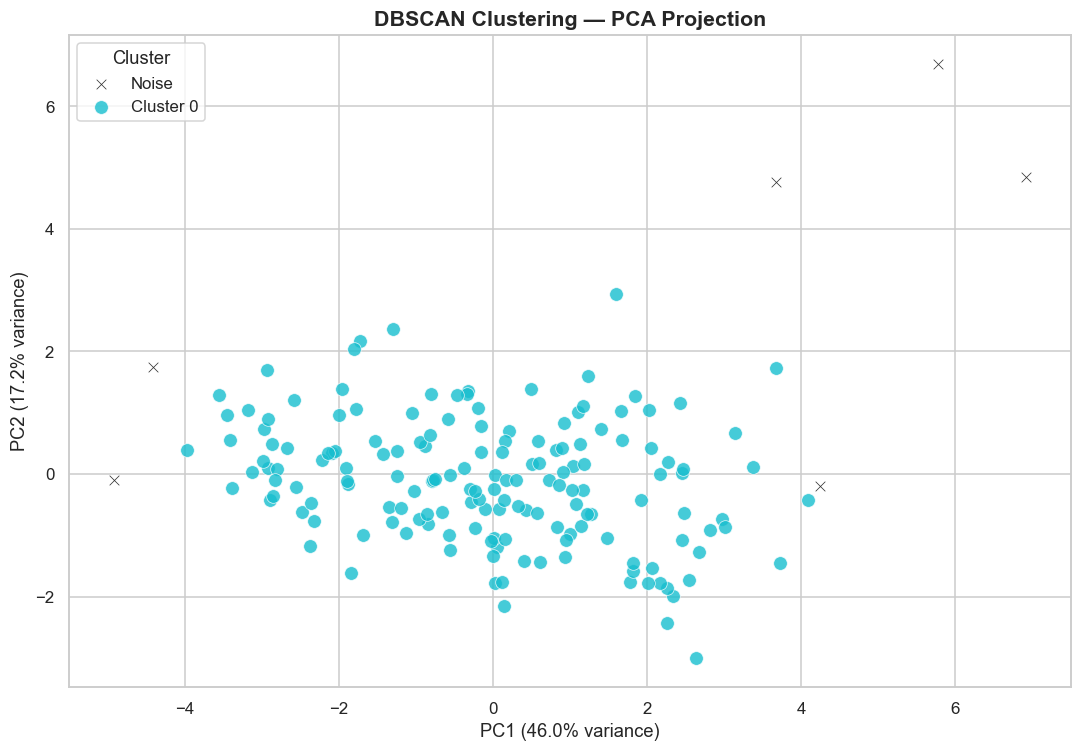

In [45]:
# ── 14. DBSCAN ───────────────────────────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors

# Find optimal eps using k-distance graph
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 4))
plt.plot(distances, color='purple', linewidth=2)
plt.xlabel('Points (sorted)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Graph (for DBSCAN eps selection)', fontweight='bold')
plt.axhline(y=2.5, color='red', linestyle='--', label='Selected eps=2.5')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', bbox_inches='tight')
plt.show()

# Apply DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f" DBSCAN Results:")
print(f"   Clusters found   : {n_clusters}")
print(f"   Noise points     : {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"   Cluster distribution: {pd.Series(dbscan_labels).value_counts().to_dict()}")

# Visualize DBSCAN
plt.figure(figsize=(10, 7))
unique_labels = sorted(set(dbscan_labels))
dbscan_palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))

for idx, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    color = 'black' if label == -1 else dbscan_palette[idx % len(dbscan_palette)]
    lname = 'Noise' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[color], label=lname, s=80 if label != -1 else 40,
                alpha=0.8, marker=marker, edgecolors='white' if label != -1 else None,
                linewidth=0.5)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('DBSCAN Clustering — PCA Projection', fontsize=14, fontweight='bold')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('dbscan_clusters.png', bbox_inches='tight')
plt.show()


##  Step 7: Label Engineering for Supervised Learning

 Label Encoding:
   0 → Developed       (36 countries)
   1 → Developing      (84 countries)
   2 → Underdeveloped  (47 countries)


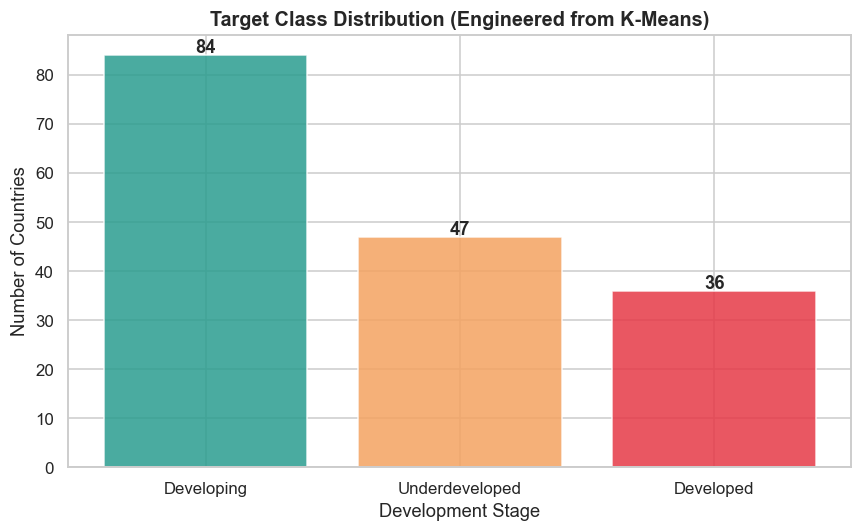


 Target variable 'y' created from K-Means cluster labels


In [46]:
# ── 15. Create Target Variable from KMeans ───────────────────────────────────
# Strategy: Use K-Means cluster labels as target for classification
# This is a valid academic pipeline: cluster → label → classify

le = LabelEncoder()
y = le.fit_transform(df['Development_Stage'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(" Label Encoding:")
for k, v in label_mapping.items():
    count = (df['Development_Stage'] == k).sum()
    print(f"   {v} → {k:15s} ({count} countries)")

# Class distribution plot
plt.figure(figsize=(8, 5))
stage_counts = df['Development_Stage'].value_counts()
bars = plt.bar(stage_counts.index, stage_counts.values,
               color=['#2A9D8F', '#F4A261', '#E63946'], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, stage_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold', fontsize=12)
plt.title('Target Class Distribution (Engineered from K-Means)', fontweight='bold', fontsize=13)
plt.xlabel('Development Stage')
plt.ylabel('Number of Countries')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

print("\n Target variable 'y' created from K-Means cluster labels")


In [47]:
# ── 16. Train / Test Split ───────────────────────────────────────────────────
X_ml = X_scaled  # scaled features

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y, test_size=0.25, random_state=42, stratify=y)

print(f" Train/Test Split (75/25):")
print(f"   Training set   : {X_train.shape[0]} samples")
print(f"   Test set       : {X_test.shape[0]} samples")
print(f"   Features       : {X_train.shape[1]}")


 Train/Test Split (75/25):
   Training set   : 125 samples
   Test set       : 42 samples
   Features       : 9


##  Step 8: Random Forest Classifier

In [48]:
# ── 17. Random Forest ────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8,
                                  min_samples_split=5, random_state=42,
                                  class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_cv  = cross_val_score(rf_model, X_ml, y, cv=5, scoring='accuracy').mean()

print(" Random Forest Results:")
print(f"   Test Accuracy       : {rf_acc*100:.2f}%")
print(f"   5-Fold CV Accuracy  : {rf_cv*100:.2f}%")
print()
print(" Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


 Random Forest Results:
   Test Accuracy       : 95.24%
   5-Fold CV Accuracy  : 95.78%

 Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         9
    Developing       0.95      0.95      0.95        21
Underdeveloped       0.92      0.92      0.92        12

      accuracy                           0.95        42
     macro avg       0.96      0.96      0.96        42
  weighted avg       0.95      0.95      0.95        42



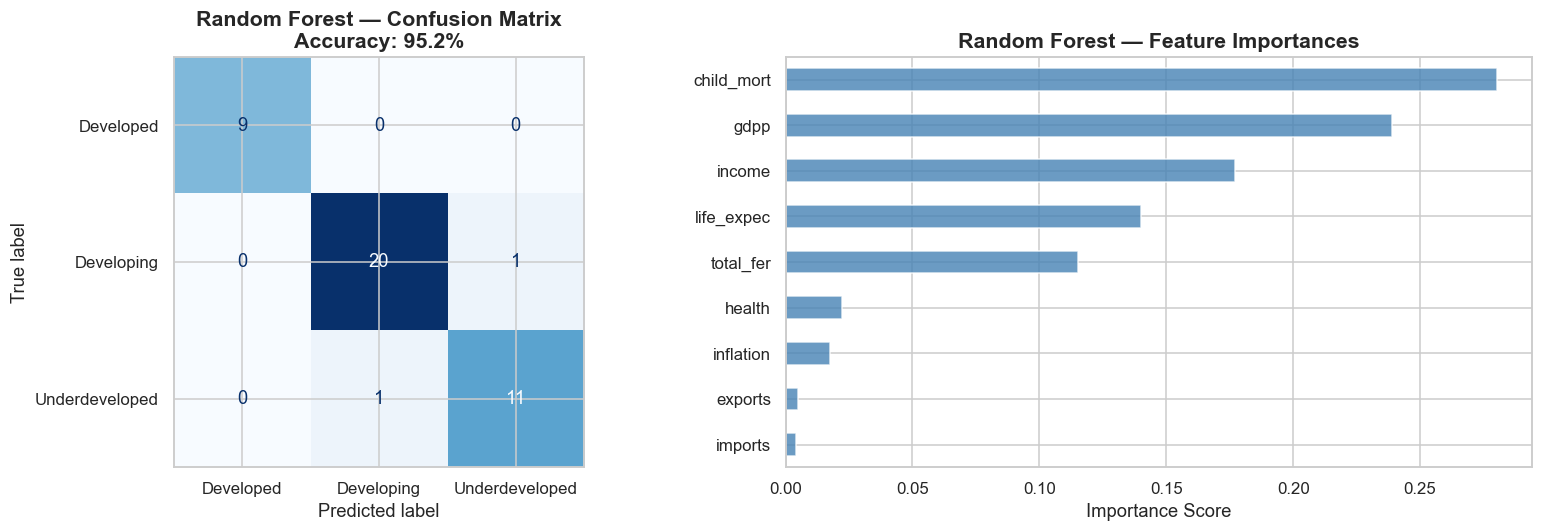

In [49]:
# ── 18. RF — Confusion Matrix & Feature Importance ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Random Forest — Confusion Matrix\nAccuracy: {rf_acc*100:.1f}%', fontweight='bold')

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('Random Forest — Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('rf_results.png', bbox_inches='tight')
plt.show()


##  Step 9: XGBoost Classifier

In [50]:
# ── 19. XGBoost ──────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_cv  = cross_val_score(xgb_model, X_ml, y, cv=5, scoring='accuracy').mean()

print("⚡ XGBoost Results:")
print(f"   Test Accuracy       : {xgb_acc*100:.2f}%")
print(f"   5-Fold CV Accuracy  : {xgb_cv*100:.2f}%")
print()
print("📋 Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))


⚡ XGBoost Results:
   Test Accuracy       : 95.24%
   5-Fold CV Accuracy  : 95.79%

📋 Classification Report:
                precision    recall  f1-score   support

     Developed       0.90      1.00      0.95         9
    Developing       0.95      0.95      0.95        21
Underdeveloped       1.00      0.92      0.96        12

      accuracy                           0.95        42
     macro avg       0.95      0.96      0.95        42
  weighted avg       0.95      0.95      0.95        42



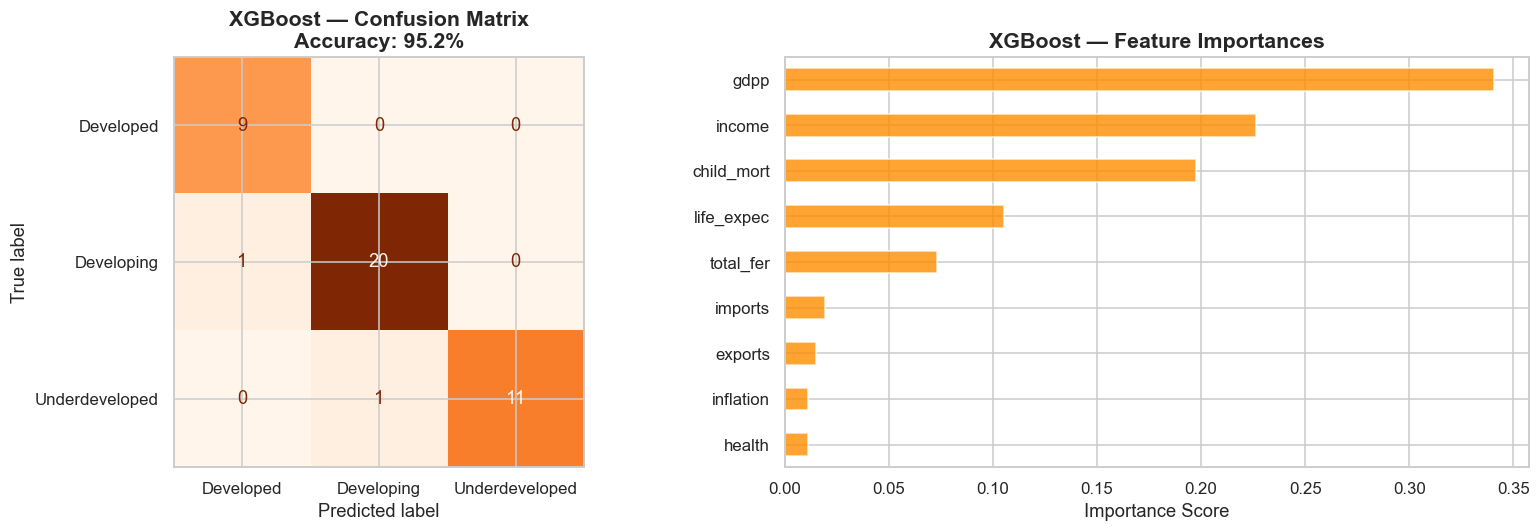

In [51]:
# ── 20. XGBoost — Confusion Matrix & Feature Importance ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(cm_xgb, display_labels=le.classes_)
disp_xgb.plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title(f'XGBoost — Confusion Matrix\nAccuracy: {xgb_acc*100:.1f}%', fontweight='bold')

# Feature Importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title('XGBoost — Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('xgb_results.png', bbox_inches='tight')
plt.show()


##  Step 10: Model Comparison & Final Evaluation

 Model Comparison:
        Model  Test Accuracy %  CV Accuracy %
Random Forest            95.24          95.78
      XGBoost            95.24          95.79


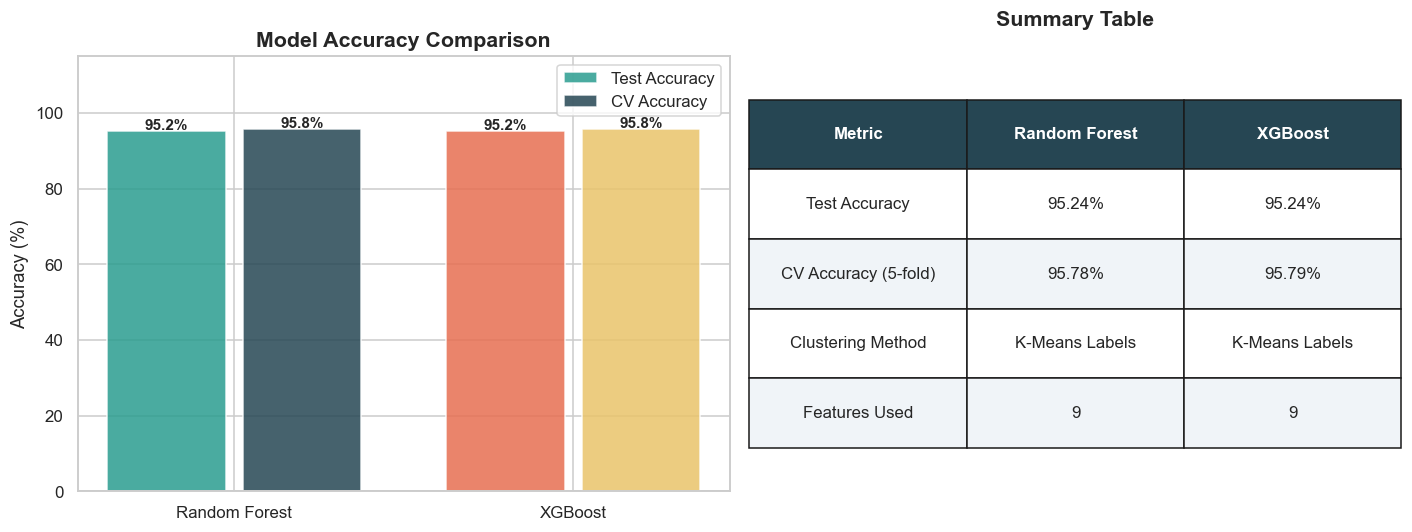

In [52]:
# ── 21. Model Comparison ─────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model'          : ['Random Forest', 'XGBoost'],
    'Test Accuracy'  : [rf_acc, xgb_acc],
    'CV Accuracy'    : [rf_cv,  xgb_cv],
})
results['Test Accuracy %'] = (results['Test Accuracy'] * 100).round(2)
results['CV Accuracy %']   = (results['CV Accuracy']   * 100).round(2)

print(" Model Comparison:")
print(results[['Model', 'Test Accuracy %', 'CV Accuracy %']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(2)
models = ['Random Forest', 'XGBoost']
test_accs = [rf_acc * 100, xgb_acc * 100]
cv_accs   = [rf_cv  * 100, xgb_cv  * 100]

bars1 = axes[0].bar(x - 0.2, test_accs, 0.35, label='Test Accuracy',
                    color=['#2A9D8F', '#E76F51'], edgecolor='white', alpha=0.85)
bars2 = axes[0].bar(x + 0.2, cv_accs,   0.35, label='CV Accuracy',
                    color=['#264653', '#E9C46A'], edgecolor='white', alpha=0.85)
for b in list(bars1) + list(bars2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f'{b.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].legend()

# Side-by-side confusion matrices overlay
axes[1].axis('off')
table_data = [['Metric', 'Random Forest', 'XGBoost'],
              ['Test Accuracy', f'{rf_acc*100:.2f}%', f'{xgb_acc*100:.2f}%'],
              ['CV Accuracy (5-fold)', f'{rf_cv*100:.2f}%', f'{xgb_cv*100:.2f}%'],
              ['Clustering Method', 'K-Means Labels', 'K-Means Labels'],
              ['Features Used', str(len(features)), str(len(features))]]
table = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                      cellLoc='center', loc='center', bbox=[0, 0.1, 1, 0.8])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#264653')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f4f8')
axes[1].set_title('Summary Table', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


##  Step 11: Business Insights & Actionable Recommendations

In [53]:
# ── 22. Final Cluster Insights ───────────────────────────────────────────────
print("=" * 65)
print("   CUSTOMER INTELLIGENCE SYSTEM — FINAL INSIGHTS")
print("=" * 65)

for stage in ['Developed', 'Developing', 'Underdeveloped']:
    subset = df[df['Development_Stage'] == stage]
    print(f"\n📌 {stage.upper()} ({len(subset)} countries)")
    print(f"   Avg Income       : ${subset['income'].mean():>10,.0f}")
    print(f"   Avg GDP per cap  : ${subset['gdpp'].mean():>10,.0f}")
    print(f"   Avg Life Expect  : {subset['life_expec'].mean():>8.1f} years")
    print(f"   Avg Child Mort   : {subset['child_mort'].mean():>8.1f} per 1000")
    print(f"   Avg Fertility    : {subset['total_fer'].mean():>8.2f}")
    print(f"   Top 5 Countries  : {', '.join(subset.nlargest(5, 'income')['country'].tolist())}")

print("\n" + "=" * 65)
print("   MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(f"   Random Forest — Test Acc : {rf_acc*100:.2f}%  |  CV Acc : {rf_cv*100:.2f}%")
print(f"   XGBoost       — Test Acc : {xgb_acc*100:.2f}%  |  CV Acc : {xgb_cv*100:.2f}%")
best_model = 'Random Forest' if rf_acc >= xgb_acc else 'XGBoost'
print(f"\n    Best Model: {best_model}")
print("=" * 65)


   CUSTOMER INTELLIGENCE SYSTEM — FINAL INSIGHTS

📌 DEVELOPED (36 countries)
   Avg Income       : $    45,672
   Avg GDP per cap  : $    42,494
   Avg Life Expect  :     80.1 years
   Avg Child Mort   :      5.0 per 1000
   Avg Fertility    :     1.75
   Top 5 Countries  : Qatar, Luxembourg, Brunei, Kuwait, Singapore

📌 DEVELOPING (84 countries)
   Avg Income       : $    12,306
   Avg GDP per cap  : $     6,486
   Avg Life Expect  :     72.8 years
   Avg Child Mort   :     21.9 per 1000
   Avg Fertility    :     2.31
   Top 5 Countries  : Saudi Arabia, Oman, Libya, Russia, Bahamas

📌 UNDERDEVELOPED (47 countries)
   Avg Income       : $     3,942
   Avg GDP per cap  : $     1,922
   Avg Life Expect  :     59.2 years
   Avg Child Mort   :     93.0 per 1000
   Avg Fertility    :     5.01
   Top 5 Countries  : Equatorial Guinea, Gabon, Botswana, Iraq, South Africa

   MODEL PERFORMANCE SUMMARY
   Random Forest — Test Acc : 95.24%  |  CV Acc : 95.78%
   XGBoost       — Test Acc : 95.24% 

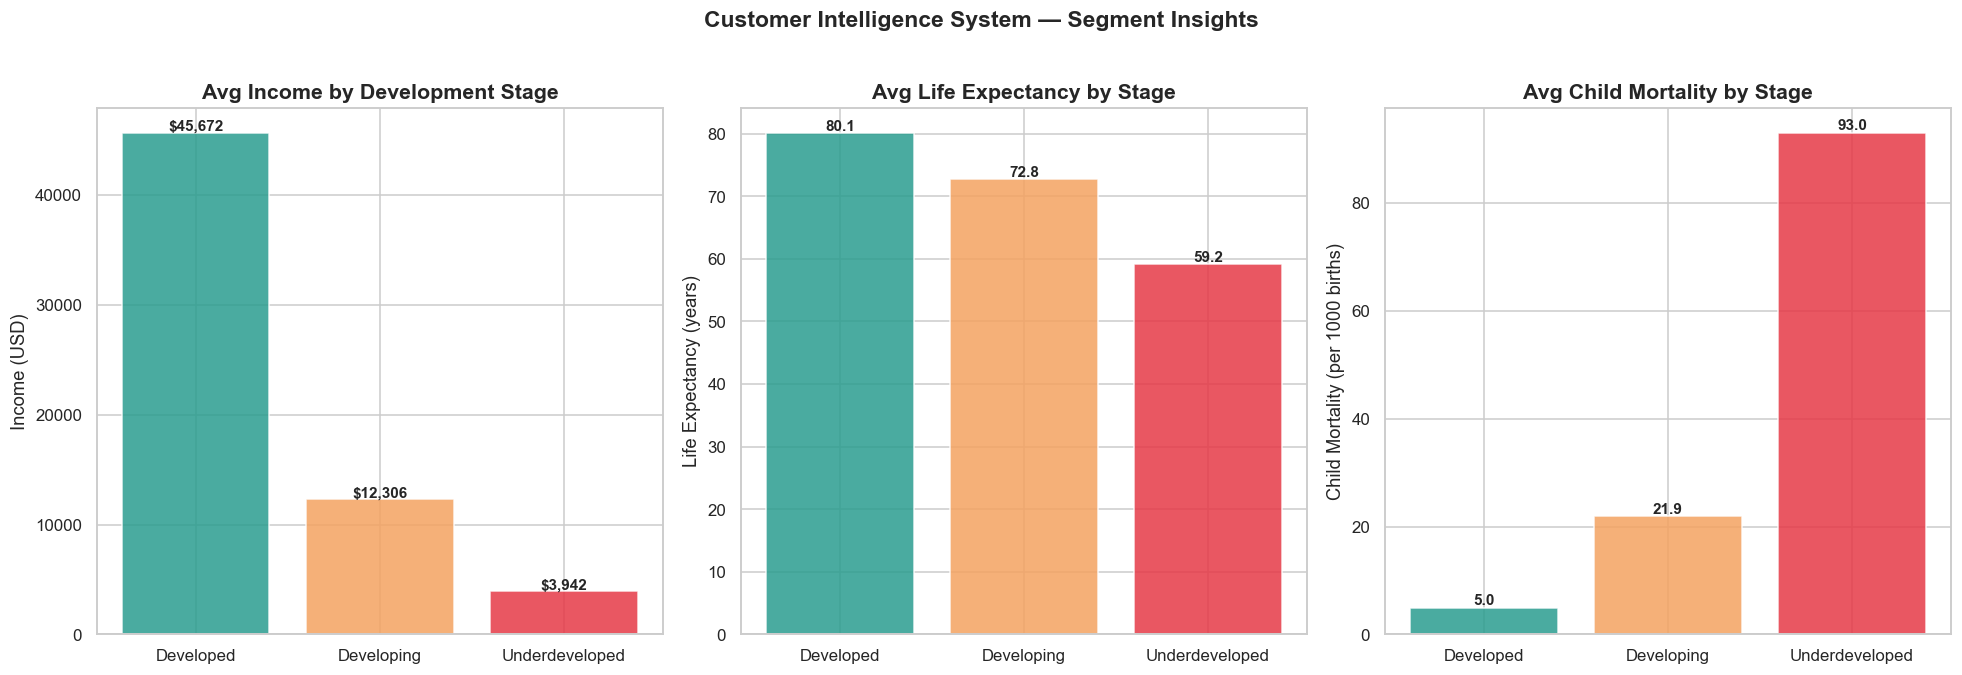


 Customer Intelligence System — Complete!
 All plots saved as .png files.


In [54]:
# ── 23. Final Summary Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

stages = ['Developed', 'Developing', 'Underdeveloped']
colors_stage = ['#2A9D8F', '#F4A261', '#E63946']

# Income comparison
income_means = [df[df['Development_Stage']==s]['income'].mean() for s in stages]
axes[0].bar(stages, income_means, color=colors_stage, edgecolor='white', alpha=0.85)
axes[0].set_title('Avg Income by Development Stage', fontweight='bold')
axes[0].set_ylabel('Income (USD)')
for i, v in enumerate(income_means):
    axes[0].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Life expectancy
life_means = [df[df['Development_Stage']==s]['life_expec'].mean() for s in stages]
axes[1].bar(stages, life_means, color=colors_stage, edgecolor='white', alpha=0.85)
axes[1].set_title('Avg Life Expectancy by Stage', fontweight='bold')
axes[1].set_ylabel('Life Expectancy (years)')
for i, v in enumerate(life_means):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

# Child mortality
mort_means = [df[df['Development_Stage']==s]['child_mort'].mean() for s in stages]
axes[2].bar(stages, mort_means, color=colors_stage, edgecolor='white', alpha=0.85)
axes[2].set_title('Avg Child Mortality by Stage', fontweight='bold')
axes[2].set_ylabel('Child Mortality (per 1000 births)')
for i, v in enumerate(mort_means):
    axes[2].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Customer Intelligence System — Segment Insights', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_insights.png', bbox_inches='tight')
plt.show()

print("\n Customer Intelligence System — Complete!")
print(" All plots saved as .png files.")
